# Конвеер экспериментальных вычислений (IVIF-TOPSIS Meta-Pipeline) (актуальная версия)

## ПАЙПЛАЙН

Загрузка данных из dataIn.json...
Загружено: 6 альтернатив, 15 критериев, 5 экспертов

🔬 ПОЛНЫЙ СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТОДОВ ДЕФАЗЗИФИКАЦИИ

📊 ПОДГОТОВКА ВЗВЕШЕННЫХ МАТРИЦ

ВЫПОЛНЕНИЕ: IVIFS-Likelihood

📊 МЕТОД: IVIFS-Likelihood
Время выполнения: 0.0032 сек
Топ-3 альтернатив:
  1. S2: Поставщик электронных компонентов (φ=0.6328)
  2. S3: Поставщик шин и резины (φ=0.5126)
  3. S5: Поставщик металлических конструкций (φ=0.5011)

ВЫПОЛНЕНИЕ: IVIFS-Score-Chen

📊 МЕТОД: IVIFS-Score-Chen
Время выполнения: 0.0009 сек
Топ-3 альтернатив:
  1. S1: Основной поставщик двигателей (φ=0.5273)
  2. S3: Поставщик шин и резины (φ=0.5218)
  3. S2: Поставщик электронных компонентов (φ=0.5072)

ВЫПОЛНЕНИЕ: IVIFS-Score-Zhang

📊 МЕТОД: IVIFS-Score-Zhang
Время выполнения: 0.0008 сек
Топ-3 альтернатив:
  1. S2: Поставщик электронных компонентов (φ=0.5378)
  2. S3: Поставщик шин и резины (φ=0.5132)
  3. S1: Основной поставщик двигателей (φ=0.5130)

ВЫПОЛНЕНИЕ: Type1-Centroid

📊 МЕТОД: Type1-Centroid
Время выпол

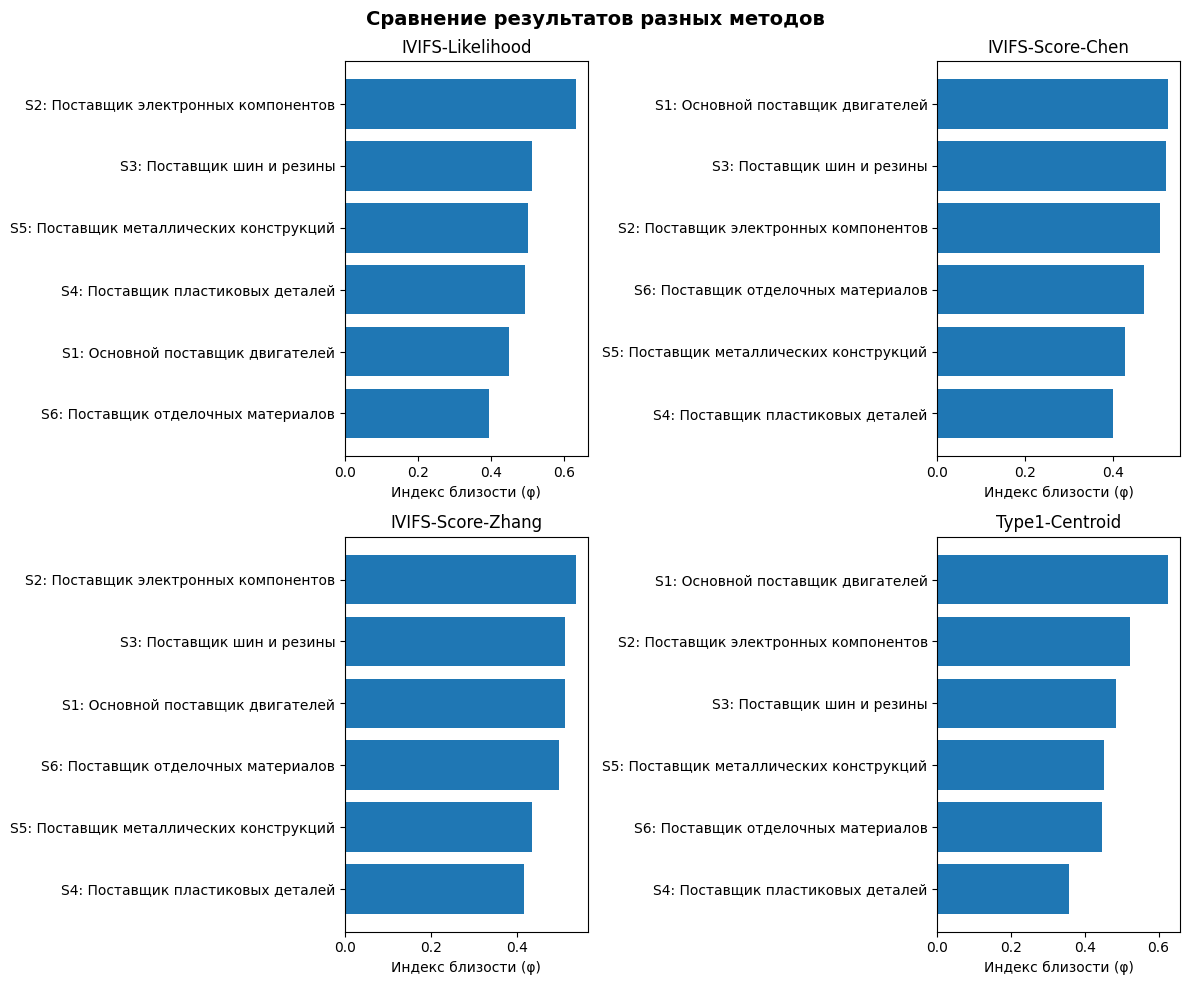

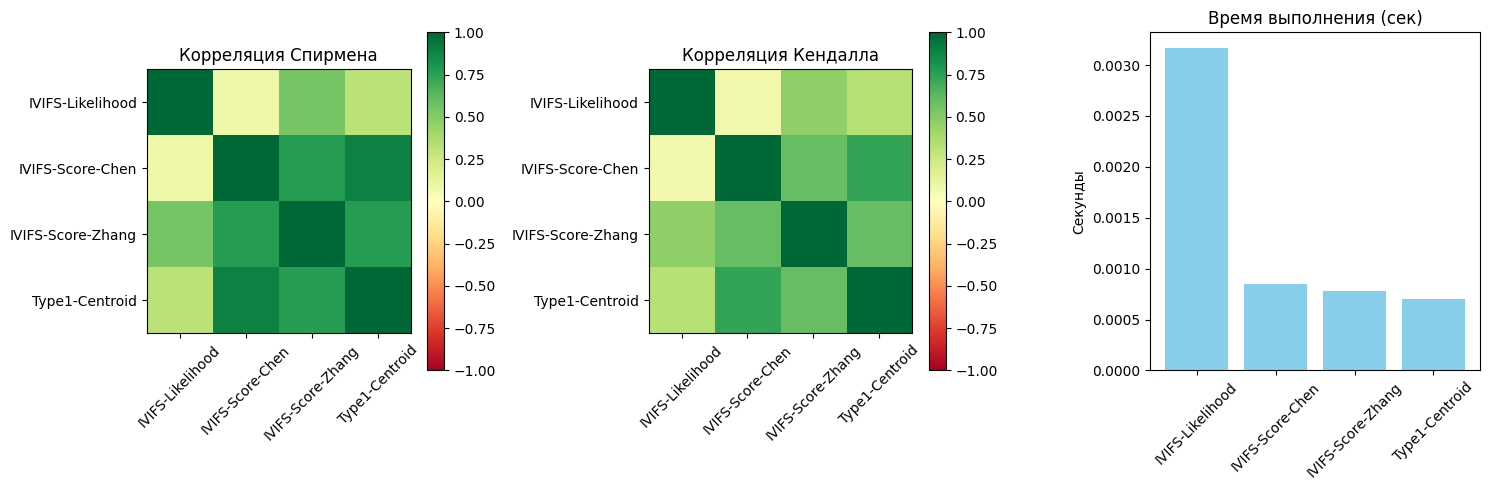

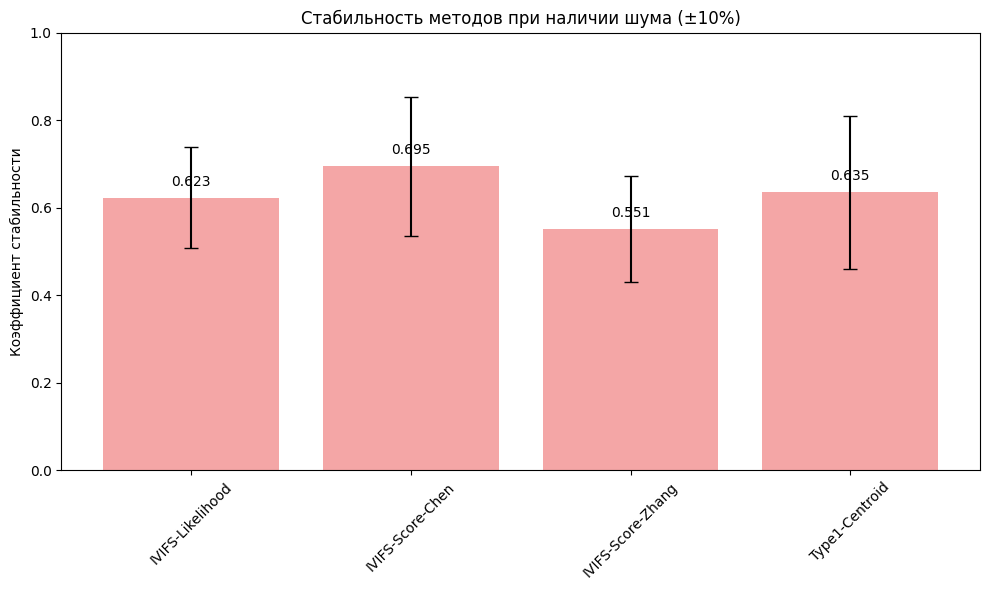

In [ ]:
import json
import numpy as np
from math import sqrt
import time
from typing import List, Dict, Tuple, Optional
from enum import Enum
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau
import warnings
warnings.filterwarnings('ignore')

# ============================================
# ОПРЕДЕЛЕНИЕ КОНСТАНТ И ТИПОВ
# ============================================

class DefuzzificationMethod(Enum):
    """Методы дефаззификации"""
    LIKELIHOOD = "IVIFS-Likelihood"      # TOPSISort-L подход
    SCORE_CHEN = "IVIFS-Score-Chen"      # Score-функция Chen (2011)
    SCORE_ZHANG = "IVIFS-Score-Zhang"    # Score-функция Zhang (2019)
    TYPE1_CENTROID = "Type1-Centroid"    # Type-1 Fuzzy с центроидом

class NoiseLevel(Enum):
    """Уровни шума для анализа чувствительности"""
    NONE = "none"
    LOW = "low"      # ±5%
    MEDIUM = "medium" # ±10%
    HIGH = "high"    # ±20%

# ============================================
# БАЗОВЫЙ КЛАСС ДЛЯ РАБОТЫ С IVIFS И TYPE-1
# ============================================

class FuzzyDataProcessor:
    """Базовый класс для обработки данных в разных форматах"""

    # Статические лингвистические термины (IVIFS формат)
    LINGUISTIC_TERMS_IVIFS = {
        "VH": [[0.75, 0.95], [0.00, 0.05]],
        "H": [[0.65, 0.75], [0.10, 0.25]],
        "MH": [[0.50, 0.65], [0.25, 0.35]],
        "F": [[0.40, 0.50], [0.35, 0.50]],
        "ML": [[0.25, 0.35], [0.50, 0.65]],
        "L": [[0.10, 0.25], [0.65, 0.75]],
        "VL": [[0.00, 0.05], [0.75, 0.95]],
        "VI": [[0.75, 0.95], [0.00, 0.05]],
        "I": [[0.65, 0.75], [0.10, 0.25]],
        "FI": [[0.50, 0.65], [0.25, 0.35]],
        "M": [[0.40, 0.50], [0.35, 0.50]],
        "FU": [[0.25, 0.35], [0.50, 0.65]],
        "U": [[0.10, 0.25], [0.65, 0.75]],
        "VU": [[0.00, 0.05], [0.75, 0.95]]
    }

    # Type-1 Fuzzy представление (треугольные числа)
    LINGUISTIC_TERMS_TYPE1 = {
        "VH": (0.8, 0.9, 1.0),    # (a, m, b) - треугольное число
        "H": (0.6, 0.75, 0.9),
        "MH": (0.4, 0.6, 0.8),
        "F": (0.3, 0.5, 0.7),
        "ML": (0.2, 0.35, 0.5),
        "L": (0.1, 0.2, 0.3),
        "VL": (0.0, 0.05, 0.1),
        "VI": (0.8, 0.9, 1.0),
        "I": (0.6, 0.75, 0.9),
        "FI": (0.4, 0.6, 0.8),
        "M": (0.3, 0.5, 0.7),
        "FU": (0.2, 0.35, 0.5),
        "U": (0.1, 0.2, 0.3),
        "VU": (0.0, 0.05, 0.1)
    }

    @staticmethod
    def linguistic_to_ivifs(term: str) -> List[List[float]]:
        """Преобразование лингвистического термина в IVIFS"""
        return FuzzyDataProcessor.LINGUISTIC_TERMS_IVIFS[term]

    @staticmethod
    def linguistic_to_type1(term: str) -> Tuple[float, float, float]:
        """Преобразование лингвистического термина в Type-1 Fuzzy"""
        return FuzzyDataProcessor.LINGUISTIC_TERMS_TYPE1[term]

    @staticmethod
    def aggregate_ivifs(ivifs_list: List[List[List[float]]],
                       weights: Optional[List[float]] = None) -> List[List[float]]:
        """Агрегация IVIFS оценок с использованием IVIFWA оператора"""
        if weights is None:
            weights = [1.0 / len(ivifs_list)] * len(ivifs_list)

        tau_min_prod = 1.0
        tau_max_prod = 1.0
        upsilon_min_prod = 1.0
        upsilon_max_prod = 1.0

        for ivifs, weight in zip(ivifs_list, weights):
            tau_min, tau_max = ivifs[0]
            upsilon_min, upsilon_max = ivifs[1]

            tau_min_prod *= (1 - tau_min) ** weight
            tau_max_prod *= (1 - tau_max) ** weight
            upsilon_min_prod *= upsilon_min ** weight
            upsilon_max_prod *= upsilon_max ** weight

        return [
            [1 - tau_min_prod, 1 - tau_max_prod],
            [upsilon_min_prod, upsilon_max_prod]
        ]

    @staticmethod
    def aggregate_type1(type1_list: List[Tuple],
                       weights: Optional[List[float]] = None) -> Tuple:
        """Агрегация Type-1 Fuzzy чисел (средневзвешенное)"""
        if weights is None:
            weights = [1.0 / len(type1_list)] * len(type1_list)

        # Для треугольных чисел: средневзвешенное каждой вершины
        a_sum, m_sum, b_sum = 0.0, 0.0, 0.0
        total_weight = sum(weights)

        for (a, m, b), w in zip(type1_list, weights):
            a_sum += a * w
            m_sum += m * w
            b_sum += b * w

        return (
            a_sum / total_weight,
            m_sum / total_weight,
            b_sum / total_weight
        )

    @staticmethod
    def multiply_ivifs(ivifs1: List[List[float]],
                      ivifs2: List[List[float]]) -> List[List[float]]:
        """Умножение двух IVIFS (для взвешивания)"""
        tau1_min, tau1_max = ivifs1[0]
        upsilon1_min, upsilon1_max = ivifs1[1]

        tau2_min, tau2_max = ivifs2[0]
        upsilon2_min, upsilon2_max = ivifs2[1]

        # Умножение для принадлежности
        tau_min = tau1_min * tau2_min
        tau_max = tau1_max * tau2_max

        # Сложение для непринадлежности
        upsilon_min = upsilon1_min + upsilon2_min - upsilon1_min * upsilon2_min
        upsilon_max = upsilon1_max + upsilon2_max - upsilon1_max * upsilon2_max

        return [[tau_min, tau_max], [upsilon_min, upsilon_max]]

    @staticmethod
    def multiply_type1(type1_num: Tuple, weight: Tuple) -> Tuple:
        """Умножение Type-1 Fuzzy числа на вес"""
        a1, m1, b1 = type1_num
        a2, m2, b2 = weight

        # Упрощённое умножение треугольных чисел
        return (
            a1 * a2,
            m1 * m2,
            b1 * b2
        )

# ============================================
# МОДУЛИ ДЕФАЗЗИФИКАЦИИ ДЛЯ КАЖДОГО МЕТОДА
# ============================================

class DefuzzificationModules:
    """Модули для всех методов дефаззификации"""

    # ========== IVIFS-LIKELIHOOD МЕТОД ==========

    @staticmethod
    def likelihood_calculate(ivifs1: List[List[float]],
                           ivifs2: List[List[float]]) -> float:
        """Расчёт правдоподобия между двумя IVIFS (TOPSISort-L)"""
        tau1_min, tau1_max = ivifs1[0]
        upsilon1_min, upsilon1_max = ivifs1[1]

        tau2_min, tau2_max = ivifs2[0]
        upsilon2_min, upsilon2_max = ivifs2[1]

        # Нижняя вероятность
        numerator_lower = (1 - upsilon2_min) - tau1_min
        denominator_lower = (1 - tau1_min - upsilon1_max) + (1 - tau2_max - upsilon2_min)
        L_lower = max(1 - max(numerator_lower/denominator_lower, 0), 0) if denominator_lower != 0 else 0

        # Верхняя вероятность
        numerator_upper = (1 - upsilon2_max) - tau1_max
        denominator_upper = (1 - tau1_max - upsilon1_min) + (1 - tau2_min - upsilon2_max)
        L_upper = max(1 - max(numerator_upper/denominator_upper, 0), 0) if denominator_upper != 0 else 0

        return 0.5 * (L_lower + L_upper)

    # ========== IVIFS-SCORE МЕТОДЫ ==========

    @staticmethod
    def score_chen(ivifs: List[List[float]]) -> float:
        """Score-функция Chen (2011)"""
        tau_min, tau_max = ivifs[0]
        upsilon_min, upsilon_max = ivifs[1]
        return (tau_min + tau_max - upsilon_min - upsilon_max) / 2

    @staticmethod
    def score_zhang(ivifs: List[List[float]]) -> float:
        """Score-функция Zhang et al. (2019)"""
        tau_min, tau_max = ivifs[0]
        upsilon_min, upsilon_max = ivifs[1]
        # Обобщённая probability-based score function
        return (tau_min + tau_max - upsilon_min - upsilon_max +
                (1 - tau_max - upsilon_min) / 2) / 2

    # ========== TYPE-1 CENTROID МЕТОД ==========

    @staticmethod
    def type1_centroid(type1_num: Tuple) -> float:
        """Дефаззификация Type-1 через центроид (центр тяжести)"""
        a, m, b = type1_num
        # Для треугольного числа центроид = (a + m + b) / 3
        return (a + m + b) / 3

    @staticmethod
    def type1_defuzzify_matrix(type1_matrix: List[List[Tuple]]) -> np.ndarray:
        """Дефаззификация всей матрицы Type-1 чисел"""
        n = len(type1_matrix)
        m = len(type1_matrix[0])
        crisp_matrix = np.zeros((n, m))

        for i in range(n):
            for j in range(m):
                crisp_matrix[i][j] = DefuzzificationModules.type1_centroid(type1_matrix[i][j])

        return crisp_matrix

# ============================================
# ОСНОВНОЙ КЛАСС КОНВЕЙЕРА С МЕТРИКАМИ
# ============================================

class TOPSISComparativePipeline:
    """Сравнительный конвейер с метриками оценки"""

    def __init__(self, data_file: str, verbose: bool = True):
        self.verbose = verbose
        self.processor = FuzzyDataProcessor()
        self.load_data(data_file)

    def load_data(self, data_file: str):
        """Загрузка данных из JSON файла"""
        with open(data_file, 'r', encoding='utf-8') as f:
            self.data = json.load(f)

        self.alternatives = self.data['alternatives']
        self.criteria = self.data['criteria']
        self.dms = self.data['dms']
        self.profiles = self.data.get('profile_boundaries', [])
        self.parameters = self.data.get('parameters', {'B': 3})
        self.B = self.parameters.get('B', 3)

        if self.verbose:
            print(f"Загружено: {len(self.alternatives)} альтернатив, "
                  f"{len(self.criteria)} критериев, {len(self.dms)} экспертов")

    def print_step(self, step_title: str):
        """Вспомогательная функция для вывода шагов"""
        if self.verbose:
            print("\n" + "="*60)
            print(f"📊 {step_title}")
            print("="*60)

    # ============================================
    # ОБЩИЕ ЭТАПЫ КОНВЕЙЕРА
    # ============================================

    def prepare_weighted_matrices(self) -> Dict:
        """Подготовка взвешенных матриц для всех форматов"""
        self.print_step("ПОДГОТОВКА ВЗВЕШЕННЫХ МАТРИЦ")

        n_alternatives = len(self.alternatives)
        n_criteria = len(self.criteria)
        n_dms = len(self.dms)

        # 1. Агрегация весов критериев (для всех форматов)
        criteria_weights_ivifs = []
        criteria_weights_type1 = []

        for j in range(n_criteria):
            # IVIFS веса
            weight_ivifs = []
            for dm in self.dms:
                term = dm['weights'][j]
                weight_ivifs.append(self.processor.linguistic_to_ivifs(term))
            aggregated_weight_ivifs = self.processor.aggregate_ivifs(weight_ivifs)
            criteria_weights_ivifs.append(aggregated_weight_ivifs)

            # Type-1 веса
            weight_type1 = []
            for dm in self.dms:
                term = dm['weights'][j]
                weight_type1.append(self.processor.linguistic_to_type1(term))
            aggregated_weight_type1 = self.processor.aggregate_type1(weight_type1)
            criteria_weights_type1.append(aggregated_weight_type1)

        # 2. Агрегация оценок альтернатив
        alternative_ratings_ivifs = []
        alternative_ratings_type1 = []

        for i in range(n_alternatives):
            alt_scores_ivifs = []
            alt_scores_type1 = []

            for j in range(n_criteria):
                # IVIFS оценки
                scores_ivifs = []
                for dm in self.dms:
                    term = dm['scores'][i][j]
                    scores_ivifs.append(self.processor.linguistic_to_ivifs(term))
                aggregated_score_ivifs = self.processor.aggregate_ivifs(scores_ivifs)
                alt_scores_ivifs.append(aggregated_score_ivifs)

                # Type-1 оценки
                scores_type1 = []
                for dm in self.dms:
                    term = dm['scores'][i][j]
                    scores_type1.append(self.processor.linguistic_to_type1(term))
                aggregated_score_type1 = self.processor.aggregate_type1(scores_type1)
                alt_scores_type1.append(aggregated_score_type1)

            alternative_ratings_ivifs.append(alt_scores_ivifs)
            alternative_ratings_type1.append(alt_scores_type1)

        # 3. Построение взвешенных матриц
        weighted_matrix_ivifs = []
        weighted_matrix_type1 = []

        for i in range(n_alternatives):
            weighted_ivifs = []
            weighted_type1 = []

            for j in range(n_criteria):
                # IVIFS: rating ⊗ weight
                weighted_ivif = self.processor.multiply_ivifs(
                    alternative_ratings_ivifs[i][j],
                    criteria_weights_ivifs[j]
                )
                weighted_ivifs.append(weighted_ivif)

                # Type-1: rating ⊗ weight
                weighted_type1_num = self.processor.multiply_type1(
                    alternative_ratings_type1[i][j],
                    criteria_weights_type1[j]
                )
                weighted_type1.append(weighted_type1_num)

            weighted_matrix_ivifs.append(weighted_ivifs)
            weighted_matrix_type1.append(weighted_type1)

        return {
            'ivifs': weighted_matrix_ivifs,
            'type1': weighted_matrix_type1,
            'criteria_weights_ivifs': criteria_weights_ivifs,
            'criteria_weights_type1': criteria_weights_type1
        }

    # ============================================
    # МЕТОДЫ ДЕФАЗЗИФИКАЦИИ
    # ============================================

    def method_ivifs_likelihood(self, weighted_matrix_ivifs: List) -> np.ndarray:
        """Метод 1: IVIFS-Likelihood (TOPSISort-L)"""
        n = len(weighted_matrix_ivifs)
        m = len(self.criteria)
        likelihood_matrix = np.zeros((n, m))

        for j in range(m):
            for i in range(n):
                sum_likelihood = 0
                count = 0
                for k in range(n):
                    if i != k:
                        likelihood = DefuzzificationModules.likelihood_calculate(
                            weighted_matrix_ivifs[i][j],
                            weighted_matrix_ivifs[k][j]
                        )
                        if self.criteria[j]['type'] == 'positive':
                            sum_likelihood += likelihood
                        else:  # negative criterion
                            sum_likelihood += (1 - likelihood)
                        count += 1
                likelihood_matrix[i][j] = sum_likelihood / count if count > 0 else 0

        return likelihood_matrix

    def method_ivifs_score_chen(self, weighted_matrix_ivifs: List) -> np.ndarray:
        """Метод 2: IVIFS-Score (Chen)"""
        n = len(weighted_matrix_ivifs)
        m = len(self.criteria)
        score_matrix = np.zeros((n, m))

        for i in range(n):
            for j in range(m):
                score_matrix[i][j] = DefuzzificationModules.score_chen(
                    weighted_matrix_ivifs[i][j]
                )

        return score_matrix

    def method_ivifs_score_zhang(self, weighted_matrix_ivifs: List) -> np.ndarray:
        """Метод 3: IVIFS-Score (Zhang)"""
        n = len(weighted_matrix_ivifs)
        m = len(self.criteria)
        score_matrix = np.zeros((n, m))

        for i in range(n):
            for j in range(m):
                score_matrix[i][j] = DefuzzificationModules.score_zhang(
                    weighted_matrix_ivifs[i][j]
                )

        return score_matrix

    def method_type1_centroid(self, weighted_matrix_type1: List) -> np.ndarray:
        """Метод 4: Type-1 Centroid"""
        return DefuzzificationModules.type1_defuzzify_matrix(weighted_matrix_type1)

    # ============================================
    # КЛАССИЧЕСКИЙ TOPSIS ДЛЯ ЧЁТКИХ МАТРИЦ
    # ============================================

    def classical_topsis(self, decision_matrix: np.ndarray) -> Dict:
        """Классический TOPSIS для чёткой матрицы решений"""
        n, m = decision_matrix.shape

        # 1. Нормализация (векторная)
        normalized_matrix = np.zeros((n, m))
        for j in range(m):
            denominator = sqrt(np.sum(decision_matrix[:, j]**2))
            if denominator > 0:
                normalized_matrix[:, j] = decision_matrix[:, j] / denominator

        # 2. Определение идеальных решений
        PIS = []
        NIS = []

        for j in range(m):
            column = normalized_matrix[:, j]
            if self.criteria[j]['type'] == 'positive':
                PIS.append(np.max(column))
                NIS.append(np.min(column))
            else:  # negative
                PIS.append(np.min(column))
                NIS.append(np.max(column))

        # 3. Расстояния и индекс близости
        distances_PIS = []
        distances_NIS = []
        closeness_index = []

        for i in range(n):
            dist_pis = sqrt(np.sum((normalized_matrix[i] - PIS)**2))
            dist_nis = sqrt(np.sum((normalized_matrix[i] - NIS)**2))

            ci = dist_nis / (dist_pis + dist_nis) if (dist_pis + dist_nis) > 0 else 0

            distances_PIS.append(dist_pis)
            distances_NIS.append(dist_nis)
            closeness_index.append(ci)

        # 4. Ранжирование
        ranked_indices = np.argsort(closeness_index)[::-1]
        ranking = []

        for rank, idx in enumerate(ranked_indices):
            ranking.append({
                'alternative': self.alternatives[idx],
                'rank': rank + 1,
                'closeness_index': closeness_index[idx],
                'distance_pis': distances_PIS[idx],
                'distance_nis': distances_NIS[idx]
            })

        return {
            'closeness_index': closeness_index,
            'ranking': ranking,
            'distances_PIS': distances_PIS,
            'distances_NIS': distances_NIS,
            'PIS': PIS,
            'NIS': NIS
        }

    # ============================================
    # ЗАПУСК ОДНОГО МЕТОДА
    # ============================================

    def run_single_method(self, method: DefuzzificationMethod,
                         weighted_matrices: Dict) -> Dict:
        """Запуск одного метода дефаззификации"""
        start_time = time.time()

        self.print_step(f"МЕТОД: {method.value}")

        # Выбор метода дефаззификации
        if method == DefuzzificationMethod.LIKELIHOOD:
            decision_matrix = self.method_ivifs_likelihood(weighted_matrices['ivifs'])
        elif method == DefuzzificationMethod.SCORE_CHEN:
            decision_matrix = self.method_ivifs_score_chen(weighted_matrices['ivifs'])
        elif method == DefuzzificationMethod.SCORE_ZHANG:
            decision_matrix = self.method_ivifs_score_zhang(weighted_matrices['ivifs'])
        elif method == DefuzzificationMethod.TYPE1_CENTROID:
            decision_matrix = self.method_type1_centroid(weighted_matrices['type1'])
        else:
            raise ValueError(f"Неизвестный метод: {method}")

        # Применение классического TOPSIS
        results = self.classical_topsis(decision_matrix)

        # Добавление метаданных
        execution_time = time.time() - start_time
        results.update({
            'method': method.value,
            'execution_time': execution_time,
            'decision_matrix_shape': decision_matrix.shape,
            'decision_matrix_sample': decision_matrix[:3].tolist() if len(decision_matrix) > 3 else decision_matrix.tolist()
        })

        if self.verbose:
            print(f"Время выполнения: {execution_time:.4f} сек")
            print("Топ-3 альтернатив:")
            for i, item in enumerate(results['ranking'][:3]):
                print(f"  {item['rank']}. {item['alternative']} (φ={item['closeness_index']:.4f})")

        return results

    # ============================================
    # МЕТРИКИ СРАВНЕНИЯ
    # ============================================

    def calculate_similarity_metrics(self, all_results: Dict) -> Dict:
        """Расчёт метрик сравнения между методами"""
        self.print_step("РАСЧЁТ МЕТРИК СРАВНЕНИЯ")

        methods = list(all_results.keys())
        n_methods = len(methods)

        metrics = {
            'spearman_correlation': np.zeros((n_methods, n_methods)),
            'kendall_correlation': np.zeros((n_methods, n_methods)),
            'top_k_similarity': {
                'top3': np.zeros((n_methods, n_methods)),
                'top5': np.zeros((n_methods, n_methods))
            },
            'execution_times': {},
            'ranking_changes': {}
        }

        # 1. Получение рангов для каждого метода
        rankings_dict = {}
        for method in methods:
            ranking = all_results[method]['ranking']
            rank_dict = {item['alternative']: item['rank'] for item in ranking}
            rankings_dict[method] = rank_dict

        # 2. Попарное сравнение
        for i in range(n_methods):
            method_i = methods[i]
            ranks_i = [rankings_dict[method_i][alt] for alt in self.alternatives]
            metrics['execution_times'][method_i] = all_results[method_i]['execution_time']

            for j in range(n_methods):
                if i == j:
                    metrics['spearman_correlation'][i][j] = 1.0
                    metrics['kendall_correlation'][i][j] = 1.0
                    metrics['top_k_similarity']['top3'][i][j] = 1.0
                    metrics['top_k_similarity']['top5'][i][j] = 1.0
                    continue

                method_j = methods[j]
                ranks_j = [rankings_dict[method_j][alt] for alt in self.alternatives]

                # Коэффициент Спирмена
                rho, _ = spearmanr(ranks_i, ranks_j)
                metrics['spearman_correlation'][i][j] = rho

                # Тау Кендалла
                tau, _ = kendalltau(ranks_i, ranks_j)
                metrics['kendall_correlation'][i][j] = tau

                # Сходство топ-K
                top3_i = {item['alternative'] for item in all_results[method_i]['ranking'][:3]}
                top3_j = {item['alternative'] for item in all_results[method_j]['ranking'][:3]}
                top5_i = {item['alternative'] for item in all_results[method_i]['ranking'][:5]}
                top5_j = {item['alternative'] for item in all_results[method_j]['ranking'][:5]}

                metrics['top_k_similarity']['top3'][i][j] = len(top3_i & top3_j) / 3
                metrics['top_k_similarity']['top5'][i][j] = len(top5_i & top5_j) / 5

        # 3. Анализ изменений рангов
        reference_method = methods[0]  # Используем первый метод как эталон
        reference_ranking = {item['alternative']: item['rank'] for item in all_results[reference_method]['ranking']}

        for method in methods[1:]:
            current_ranking = {item['alternative']: item['rank'] for item in all_results[method]['ranking']}
            rank_changes = []

            for alt in self.alternatives:
                change = current_ranking[alt] - reference_ranking[alt]
                rank_changes.append({
                    'alternative': alt,
                    'reference_rank': reference_ranking[alt],
                    'current_rank': current_ranking[alt],
                    'change': change
                })

            metrics['ranking_changes'][method] = rank_changes

        return metrics

    def analyze_sensitivity(self, weighted_matrices: Dict,
                          noise_level: NoiseLevel = NoiseLevel.MEDIUM) -> Dict:
        """Анализ чувствительности к возмущениям в данных"""
        self.print_step(f"АНАЛИЗ ЧУВСТВИТЕЛЬНОСТИ (шум: {noise_level.value})")

        # Определение уровня шума
        if noise_level == NoiseLevel.LOW:
            noise_range = 0.05
        elif noise_level == NoiseLevel.MEDIUM:
            noise_range = 0.10
        elif noise_level == NoiseLevel.HIGH:
            noise_range = 0.20
        else:
            noise_range = 0.0

        sensitivity_results = {}

        for method in DefuzzificationMethod:
            print(f"\nАнализ метода: {method.value}")

            # Базовое выполнение (без шума)
            base_result = self.run_single_method(method, weighted_matrices)
            base_ranking = {item['alternative']: item['rank'] for item in base_result['ranking']}

            # Многократное выполнение с шумом
            n_iterations = 10
            rank_stabilities = []

            for iteration in range(n_iterations):
                # Добавление шума к данным
                noisy_matrices = self.add_noise_to_data(weighted_matrices, noise_range)

                # Выполнение с зашумлёнными данными
                noisy_result = self.run_single_method(method, noisy_matrices)
                noisy_ranking = {item['alternative']: item['rank'] for item in noisy_result['ranking']}

                # Расчёт стабильности рангов
                rank_changes = []
                for alt in self.alternatives:
                    change = abs(noisy_ranking[alt] - base_ranking[alt])
                    rank_changes.append(change)

                avg_change = np.mean(rank_changes)
                rank_stabilities.append(1.0 / (1.0 + avg_change))  # Мера стабильности

            sensitivity_results[method.value] = {
                'base_ranking': base_ranking,
                'stability_mean': np.mean(rank_stabilities),
                'stability_std': np.std(rank_stabilities),
                'noise_level': noise_level.value,
                'iterations': n_iterations
            }

            print(f"  Стабильность: {sensitivity_results[method.value]['stability_mean']:.3f} "
                  f"(±{sensitivity_results[method.value]['stability_std']:.3f})")

        return sensitivity_results

    def add_noise_to_data(self, weighted_matrices: Dict,
                         noise_range: float) -> Dict:
        """Добавление шума к данным"""
        noisy_matrices = {}

        # Добавление шума к IVIFS данным
        noisy_ivifs = []
        for row in weighted_matrices['ivifs']:
            noisy_row = []
            for ivifs in row:
                tau_min, tau_max = ivifs[0]
                upsilon_min, upsilon_max = ivifs[1]

                # Добавляем шум в пределах [-noise_range, noise_range]
                tau_min_noisy = max(0, min(1, tau_min + np.random.uniform(-noise_range, noise_range)))
                tau_max_noisy = max(0, min(1, tau_max + np.random.uniform(-noise_range, noise_range)))
                upsilon_min_noisy = max(0, min(1, upsilon_min + np.random.uniform(-noise_range, noise_range)))
                upsilon_max_noisy = max(0, min(1, upsilon_max + np.random.uniform(-noise_range, noise_range)))

                # Корректировка для выполнения условия τ⁺ + υ⁺ ≤ 1
                if tau_max_noisy + upsilon_max_noisy > 1:
                    scale = 0.99 / (tau_max_noisy + upsilon_max_noisy)
                    tau_max_noisy *= scale
                    upsilon_max_noisy *= scale

                noisy_row.append([[tau_min_noisy, tau_max_noisy],
                                 [upsilon_min_noisy, upsilon_max_noisy]])
            noisy_ivifs.append(noisy_row)

        # Добавление шума к Type-1 данным
        noisy_type1 = []
        for row in weighted_matrices['type1']:
            noisy_row = []
            for type1_num in row:
                a, m, b = type1_num
                a_noisy = max(0, min(1, a + np.random.uniform(-noise_range, noise_range)))
                m_noisy = max(0, min(1, m + np.random.uniform(-noise_range, noise_range)))
                b_noisy = max(0, min(1, b + np.random.uniform(-noise_range, noise_range)))

                # Упорядочивание a ≤ m ≤ b
                a_noisy, m_noisy, b_noisy = sorted([a_noisy, m_noisy, b_noisy])
                noisy_row.append((a_noisy, m_noisy, b_noisy))
            noisy_type1.append(noisy_row)

        noisy_matrices['ivifs'] = noisy_ivifs
        noisy_matrices['type1'] = noisy_type1

        return noisy_matrices

    # ============================================
    # ОСНОВНОЙ МЕТОД ЗАПУСКА
    # ============================================

    def run_comparative_analysis(self, methods: List[DefuzzificationMethod] = None,
                               analyze_sensitivity: bool = True) -> Dict:
        """Запуск полного сравнительного анализа"""

        if methods is None:
            methods = [
                DefuzzificationMethod.LIKELIHOOD,
                DefuzzificationMethod.SCORE_CHEN,
                DefuzzificationMethod.SCORE_ZHANG,
                DefuzzificationMethod.TYPE1_CENTROID
            ]

        print("\n" + "="*80)
        print("🔬 ПОЛНЫЙ СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТОДОВ ДЕФАЗЗИФИКАЦИИ")
        print("="*80)

        # 1. Подготовка данных
        weighted_matrices = self.prepare_weighted_matrices()

        # 2. Выполнение всех методов
        all_results = {}

        for method in methods:
            print(f"\n{'='*40}")
            print(f"ВЫПОЛНЕНИЕ: {method.value}")
            print(f"{'='*40}")

            results = self.run_single_method(method, weighted_matrices)
            all_results[method.value] = results

        # 3. Расчёт метрик сравнения
        comparison_metrics = self.calculate_similarity_metrics(all_results)

        # 4. Анализ чувствительности (опционально)
        sensitivity_results = None
        if analyze_sensitivity:
            sensitivity_results = self.analyze_sensitivity(
                weighted_matrices,
                noise_level=NoiseLevel.MEDIUM
            )

        # 5. Визуализация результатов
        self.visualize_results(all_results, comparison_metrics, sensitivity_results)

        # 6. Сохранение результатов
        self.save_results(all_results, comparison_metrics, sensitivity_results)

        return {
            'all_results': all_results,
            'comparison_metrics': comparison_metrics,
            'sensitivity_results': sensitivity_results
        }

    # ============================================
    # ВИЗУАЛИЗАЦИЯ И СОХРАНЕНИЕ
    # ============================================

    def visualize_results(self, all_results: Dict,
                         comparison_metrics: Dict,
                         sensitivity_results: Optional[Dict] = None):
        """Визуализация результатов сравнения"""
        if not self.verbose:
            return

        methods = list(all_results.keys())

        # 1. Визуализация ранжирований
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        fig.suptitle('Сравнение результатов разных методов', fontsize=14, fontweight='bold')

        for idx, method in enumerate(methods):
            ax = axes[idx // 2, idx % 2]
            ranking = all_results[method]['ranking']
            closeness = [item['closeness_index'] for item in ranking]
            alternatives = [item['alternative'] for item in ranking]

            ax.barh(range(len(alternatives)), closeness)
            ax.set_yticks(range(len(alternatives)))
            ax.set_yticklabels(alternatives)
            ax.set_xlabel('Индекс близости (φ)')
            ax.set_title(f'{method}')
            ax.invert_yaxis()

        plt.tight_layout()
        plt.savefig('ranking_comparison.png', dpi=300, bbox_inches='tight')

        # 2. Визуализация корреляций
        fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))

        # Матрица корреляций Спирмена
        im1 = axes2[0].imshow(comparison_metrics['spearman_correlation'],
                             cmap='RdYlGn', vmin=-1, vmax=1)
        axes2[0].set_title('Корреляция Спирмена')
        axes2[0].set_xticks(range(len(methods)))
        axes2[0].set_xticklabels(methods, rotation=45)
        axes2[0].set_yticks(range(len(methods)))
        axes2[0].set_yticklabels(methods)
        plt.colorbar(im1, ax=axes2[0])

        # Матрица корреляций Кендалла
        im2 = axes2[1].imshow(comparison_metrics['kendall_correlation'],
                             cmap='RdYlGn', vmin=-1, vmax=1)
        axes2[1].set_title('Корреляция Кендалла')
        axes2[1].set_xticks(range(len(methods)))
        axes2[1].set_xticklabels(methods, rotation=45)
        axes2[1].set_yticks(range(len(methods)))
        axes2[1].set_yticklabels(methods)
        plt.colorbar(im2, ax=axes2[1])

        # Время выполнения
        execution_times = [all_results[method]['execution_time'] for method in methods]
        axes2[2].bar(methods, execution_times, color='skyblue')
        axes2[2].set_title('Время выполнения (сек)')
        axes2[2].set_ylabel('Секунды')
        axes2[2].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.savefig('correlation_analysis.png', dpi=300, bbox_inches='tight')

        if sensitivity_results:
            # 3. Визуализация чувствительности
            fig3, ax3 = plt.subplots(figsize=(10, 6))
            methods_sens = list(sensitivity_results.keys())
            stabilities = [sensitivity_results[method]['stability_mean'] for method in methods_sens]
            stds = [sensitivity_results[method]['stability_std'] for method in methods_sens]

            bars = ax3.bar(methods_sens, stabilities, yerr=stds,
                          capsize=5, color='lightcoral', alpha=0.7)
            ax3.set_title('Стабильность методов при наличии шума (±10%)')
            ax3.set_ylabel('Коэффициент стабильности')
            ax3.set_ylim(0, 1)
            ax3.tick_params(axis='x', rotation=45)

            # Добавление значений на столбцы
            for bar, stability in zip(bars, stabilities):
                ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                        f'{stability:.3f}', ha='center', va='bottom')

            plt.tight_layout()
            plt.savefig('sensitivity_analysis.png', dpi=300, bbox_inches='tight')

        if self.verbose:
            print("\n📊 Графики сохранены:")
            print("  - ranking_comparison.png (сравнение ранжирований)")
            print("  - correlation_analysis.png (корреляция и время)")
            if sensitivity_results:
                print("  - sensitivity_analysis.png (анализ чувствительности)")

    def save_results(self, all_results: Dict,
                    comparison_metrics: Dict,
                    sensitivity_results: Optional[Dict] = None):
        """Сохранение всех результатов в JSON файлы"""

        # 1. Основные результаты
        for method, results in all_results.items():
            filename = f"results_{method.replace('-', '_').lower()}.json"
            with open(filename, 'w', encoding='utf-8') as f:
                json.dump(results, f, ensure_ascii=False, indent=2)

        # 2. Метрики сравнения
        metrics_filename = "comparison_metrics.json"
        with open(metrics_filename, 'w', encoding='utf-8') as f:
            # Преобразование numpy массивов в списки
            metrics_to_save = {
                'spearman_correlation': comparison_metrics['spearman_correlation'].tolist(),
                'kendall_correlation': comparison_metrics['kendall_correlation'].tolist(),
                'top_k_similarity': {
                    'top3': comparison_metrics['top_k_similarity']['top3'].tolist(),
                    'top5': comparison_metrics['top_k_similarity']['top5'].tolist()
                },
                'execution_times': comparison_metrics['execution_times'],
                'methods': list(all_results.keys())
            }
            json.dump(metrics_to_save, f, ensure_ascii=False, indent=2)

        # 3. Результаты чувствительности
        if sensitivity_results:
            sensitivity_filename = "sensitivity_results.json"
            with open(sensitivity_filename, 'w', encoding='utf-8') as f:
                json.dump(sensitivity_results, f, ensure_ascii=False, indent=2)

        if self.verbose:
            print("\n💾 Результаты сохранены в файлы:")
            for method in all_results.keys():
                print(f"  - results_{method.replace('-', '_').lower()}.json")
            print(f"  - comparison_metrics.json")
            if sensitivity_results:
                print(f"  - sensitivity_results.json")

# ============================================
# ЗАПУСК АНАЛИЗА
# ============================================

if __name__ == "__main__":
    try:
        # Инициализация конвейера
        print("Загрузка данных из dataIn.json...")
        pipeline = TOPSISComparativePipeline('dataIn.json', verbose=True)

        # Запуск полного анализа
        results = pipeline.run_comparative_analysis(
            methods=[
                DefuzzificationMethod.LIKELIHOOD,
                DefuzzificationMethod.SCORE_CHEN,
                DefuzzificationMethod.SCORE_ZHANG,
                DefuzzificationMethod.TYPE1_CENTROID
            ],
            analyze_sensitivity=True
        )

        print("\n" + "="*80)
        print("✅ АНАЛИЗ УСПЕШНО ЗАВЕРШЕН")
        print("="*80)

        # Вывод сводной информации
        print("\n📋 СВОДКА РЕЗУЛЬТАТОВ:")

        metrics = results['comparison_metrics']
        methods = list(results['all_results'].keys())

        print(f"\nМетоды: {', '.join(methods)}")
        print(f"\nСредняя корреляция Спирмена между методами: "
              f"{np.mean(metrics['spearman_correlation'][np.triu_indices(len(methods), 1)]):.4f}")
        print(f"Среднее время выполнения: "
              f"{np.mean(list(metrics['execution_times'].values())):.4f} сек")

        if results['sensitivity_results']:
            print(f"\nАнализ чувствительности (шум ±10%):")
            for method, sens in results['sensitivity_results'].items():
                print(f"  {method}: стабильность = {sens['stability_mean']:.3f}")

    except FileNotFoundError:
        print("❌ Ошибка: Файл dataIn.json не найден!")
        print("Создайте файл dataIn.json или укажите правильный путь")
    except Exception as e:
        print(f"❌ Ошибка при выполнении анализа: {str(e)}")
        import traceback
        traceback.print_exc()

## Использование пайплайна

In [ ]:
# 1. Создайте файл dataIn.json с вашими данными
# 2. Запустите конвейер
pipeline = TOPSISComparativePipeline('dataIn.json', verbose=True)
results = pipeline.run_comparative_analysis(analyze_sensitivity=True)

# 3. Анализируйте результаты
print("Корреляция Спирмена:", results['comparison_metrics']['spearman_correlation'])
print("Сходство топ-3:", results['comparison_metrics']['top_k_similarity']['top3'])
print("Стабильность методов:", results['sensitivity_results'])

NameError: name 'TOPSISComparativePipeline' is not defined

## Последовательное тестирование

Загружено: 4 альтернатив, 5 критериев, 4 экспертов

🔬 ПОЛНЫЙ СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТОДОВ ДЕФАЗЗИФИКАЦИИ

📊 ПОДГОТОВКА ВЗВЕШЕННЫХ МАТРИЦ

ВЫПОЛНЕНИЕ: IVIFS-Likelihood

📊 МЕТОД: IVIFS-Likelihood
Время выполнения: 0.0108 сек
Топ-3 альтернатив:
  1. Кандидат Delta (φ=0.6277)
  2. Кандидат Alpha (φ=0.6216)
  3. Кандидат Beta (φ=0.5715)

ВЫПОЛНЕНИЕ: IVIFS-Score-Chen

📊 МЕТОД: IVIFS-Score-Chen
Время выполнения: 0.0005 сек
Топ-3 альтернатив:
  1. Кандидат Gamma (φ=0.8217)
  2. Кандидат Beta (φ=0.7350)
  3. Кандидат Delta (φ=0.3263)

ВЫПОЛНЕНИЕ: IVIFS-Score-Zhang

📊 МЕТОД: IVIFS-Score-Zhang
Время выполнения: 0.0004 сек
Топ-3 альтернатив:
  1. Кандидат Gamma (φ=0.8860)
  2. Кандидат Beta (φ=0.7288)
  3. Кандидат Delta (φ=0.3028)

ВЫПОЛНЕНИЕ: Type1-Centroid

📊 МЕТОД: Type1-Centroid
Время выполнения: 0.0003 сек
Топ-3 альтернатив:
  1. Кандидат Gamma (φ=0.7766)
  2. Кандидат Beta (φ=0.6529)
  3. Кандидат Delta (φ=0.3421)

📊 РАСЧЁТ МЕТРИК СРАВНЕНИЯ

📊 АНАЛИЗ ЧУВСТВИТЕЛЬНОСТИ (шум: medium)

Анализ м

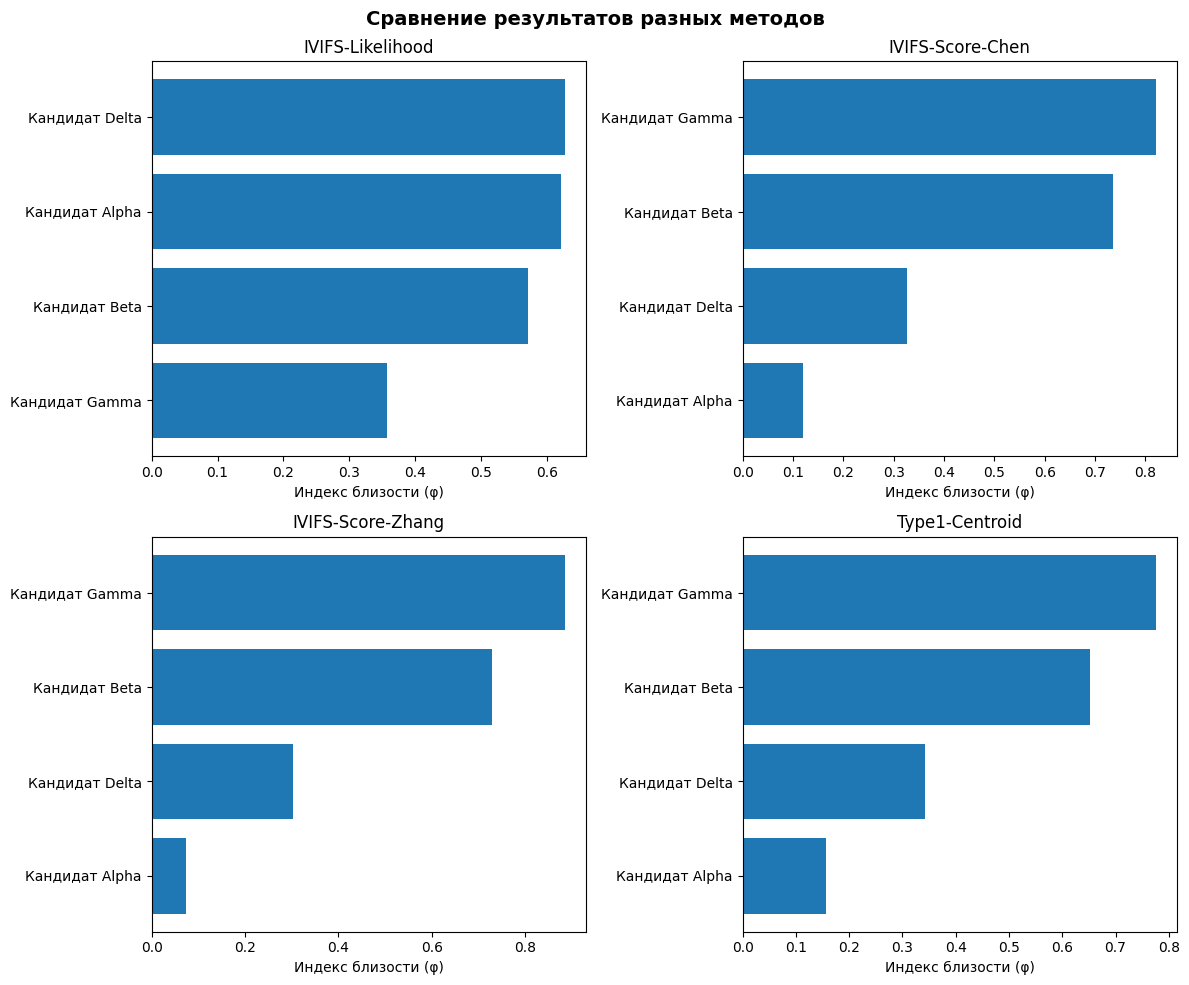

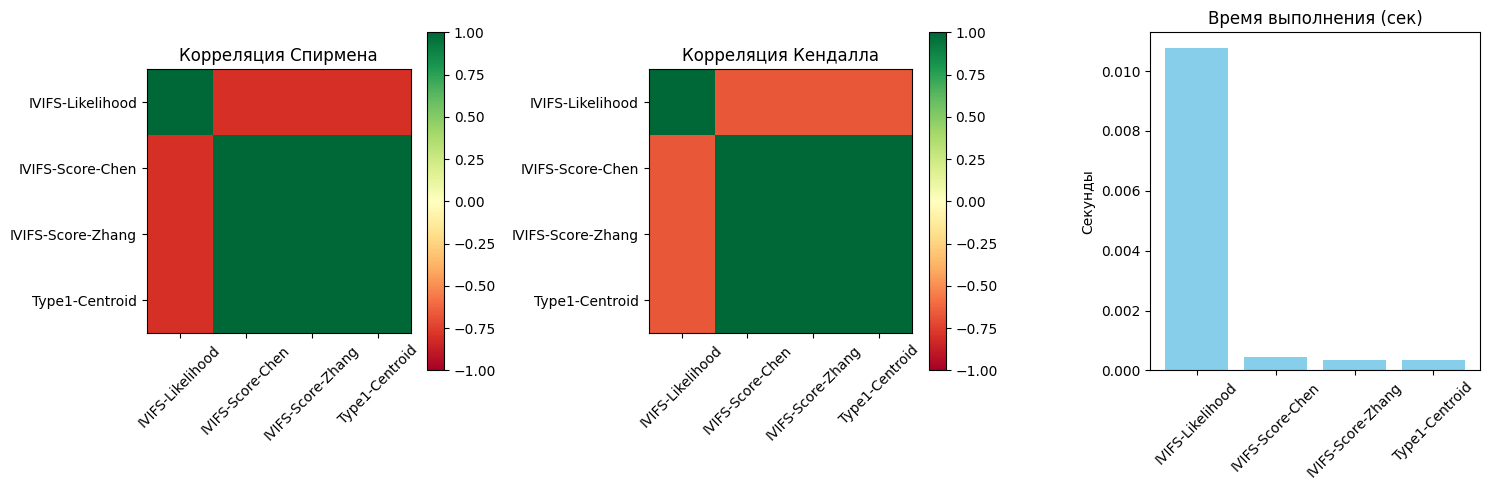

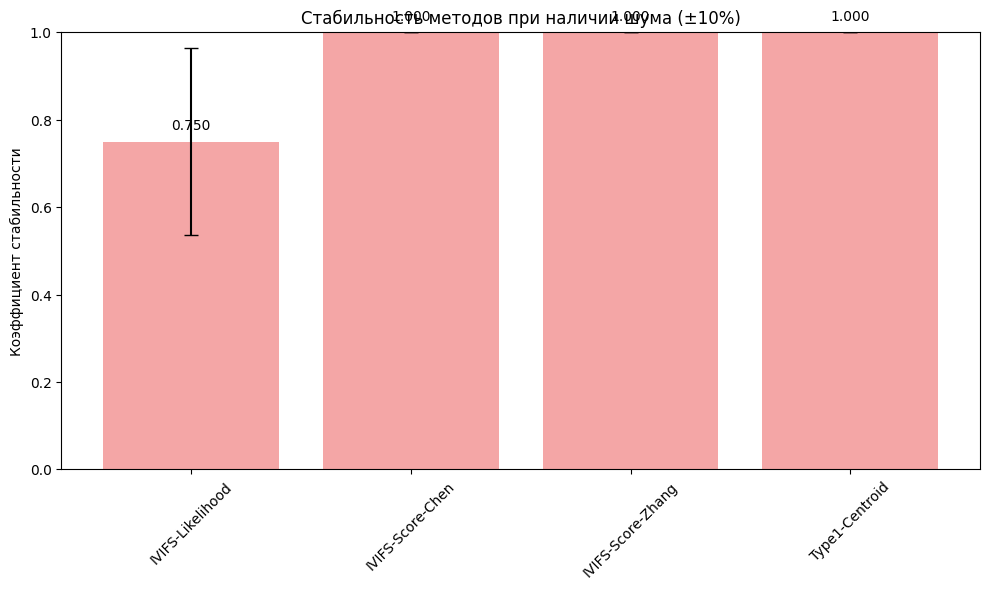

In [ ]:
# # Простой случай
# pipeline = TOPSISComparativePipeline('1set.json') #case_study_1_consistent.json
# results1 = pipeline.run_comparative_analysis()

# # Умеренная сложность
# pipeline = TOPSISComparativePipeline('2set.json') #case_study_2_moderate.json
# results2 = pipeline.run_comparative_analysis()

# Сложный случай
pipeline = TOPSISComparativePipeline('3set.json') #case_study_3_conflicting.json
results3 = pipeline.run_comparative_analysis()

# ПАЙПЛАЙН для сравнения дефаззификации (старая версия)

In [ ]:
import json
import numpy as np
from math import sqrt
from enum import Enum
from typing import List, Dict, Tuple, Optional
import matplotlib.pyplot as plt

# ============================================
# ОПРЕДЕЛЕНИЕ КОНСТАНТ И ТИПОВ
# ============================================

class DefuzzificationMethod(Enum):
    """Методы дефаззификации/обработки IVIFS"""
    LIKELIHOOD = "likelihood"      # TOPSISort-L подход
    SCORE_FUNCTION = "score"       # Score-функция
    DIRECT_DISTANCE = "distance"   # Прямое расстояние

class ClassificationMethod(Enum):
    """Методы классификации"""
    WITH_PROFILES = "with_profiles"
    BY_CLOSENESS = "by_closeness"
    BY_DISTANCE_PIS = "by_distance_pis"
    BY_DISTANCE_NIS = "by_distance_nis"

# ============================================
# БАЗОВЫЙ КЛАСС ДЛЯ РАБОТЫ С IVIFS
# ============================================

class IVIFSProcessor:
    """Базовый класс для обработки IVIFS данных"""

    # Статические лингвистические термины
    LINGUISTIC_TERMS = {
        "VH": [[0.75, 0.95], [0.00, 0.05]],
        "H": [[0.65, 0.75], [0.10, 0.25]],
        "MH": [[0.50, 0.65], [0.25, 0.35]],
        "F": [[0.40, 0.50], [0.35, 0.50]],
        "ML": [[0.25, 0.35], [0.50, 0.65]],
        "L": [[0.10, 0.25], [0.65, 0.75]],
        "VL": [[0.00, 0.05], [0.75, 0.95]],
        "VI": [[0.75, 0.95], [0.00, 0.05]],
        "I": [[0.65, 0.75], [0.10, 0.25]],
        "FI": [[0.50, 0.65], [0.25, 0.35]],
        "M": [[0.40, 0.50], [0.35, 0.50]],
        "FU": [[0.25, 0.35], [0.50, 0.65]],
        "U": [[0.10, 0.25], [0.65, 0.75]],
        "VU": [[0.00, 0.05], [0.75, 0.95]]
    }

    @staticmethod
    def linguistic_to_ivifs(term: str) -> List[List[float]]:
        """Преобразование лингвистического термина в IVIFS"""
        return IVIFSProcessor.LINGUISTIC_TERMS[term]

    @staticmethod
    def aggregate_ivifs(ivifs_list: List[List[List[float]]],
                        weights: Optional[List[float]] = None) -> List[List[float]]:
        """Агрегация IVIFS оценок с использованием IVIFWA оператора"""
        if weights is None:
            weights = [1.0 / len(ivifs_list)] * len(ivifs_list)

        tau_min_prod = 1.0
        tau_max_prod = 1.0
        upsilon_min_prod = 1.0
        upsilon_max_prod = 1.0

        for ivifs, weight in zip(ivifs_list, weights):
            tau_min, tau_max = ivifs[0]
            upsilon_min, upsilon_max = ivifs[1]

            tau_min_prod *= (1 - tau_min) ** weight
            tau_max_prod *= (1 - tau_max) ** weight
            upsilon_min_prod *= upsilon_min ** weight
            upsilon_max_prod *= upsilon_max ** weight

        return [
            [1 - tau_min_prod, 1 - tau_max_prod],
            [upsilon_min_prod, upsilon_max_prod]
        ]

    @staticmethod
    def multiply_ivifs(ivifs1: List[List[float]],
                       ivifs2: List[List[float]]) -> List[List[float]]:
        """Умножение двух IVIFS (для взвешивания)"""
        tau1_min, tau1_max = ivifs1[0]
        upsilon1_min, upsilon1_max = ivifs1[1]

        tau2_min, tau2_max = ivifs2[0]
        upsilon2_min, upsilon2_max = ivifs2[1]

        # Умножение для принадлежности
        tau_min = tau1_min * tau2_min
        tau_max = tau1_max * tau2_max

        # Сложение для непринадлежности
        upsilon_min = upsilon1_min + upsilon2_min - upsilon1_min * upsilon2_min
        upsilon_max = upsilon1_max + upsilon2_max - upsilon1_max * upsilon2_max

        return [[tau_min, tau_max], [upsilon_min, upsilon_max]]

# ============================================
# МОДУЛИ ДЕФАЗЗИФИКАЦИИ
# ============================================

class DefuzzificationModule:
    """Модуль для различных методов дефаззификации"""

    @staticmethod
    def calculate_likelihood(ivifs1: List[List[float]],
                           ivifs2: List[List[float]]) -> float:
        """Расчёт правдоподобия между двумя IVIFS (TOPSISort-L подход)"""
        tau1_min, tau1_max = ivifs1[0]
        upsilon1_min, upsilon1_max = ivifs1[1]

        tau2_min, tau2_max = ivifs2[0]
        upsilon2_min, upsilon2_max = ivifs2[1]

        # Нижняя вероятность
        numerator_lower = (1 - upsilon2_min) - tau1_min
        denominator_lower = (1 - tau1_min - upsilon1_max) + (1 - tau2_max - upsilon2_min)
        L_lower = max(1 - max(numerator_lower/denominator_lower, 0), 0) if denominator_lower != 0 else 0

        # Верхняя вероятность
        numerator_upper = (1 - upsilon2_max) - tau1_max
        denominator_upper = (1 - tau1_max - upsilon1_min) + (1 - tau2_min - upsilon2_max)
        L_upper = max(1 - max(numerator_upper/denominator_upper, 0), 0) if denominator_upper != 0 else 0

        # Общая вероятность
        return 0.5 * (L_lower + L_upper)

    @staticmethod
    def calculate_score(ivifs: List[List[float]],
                       method: str = "chen") -> float:
        """Расчёт score-функции для IVIFS"""
        tau_min, tau_max = ivifs[0]
        upsilon_min, upsilon_max = ivifs[1]

        if method == "chen":
            # Chen (2011) score function
            return (tau_min + tau_max - upsilon_min - upsilon_max) / 2
        elif method == "zhang":
            # Zhang et al. (2019) generalized score function
            return (tau_min + tau_max - upsilon_min - upsilon_max +
                    (1 - tau_max - upsilon_min) / 2) / 2
        else:
            # Базовая score-функция
            return (tau_min + tau_max - upsilon_min - upsilon_max) / 2

    @staticmethod
    def calculate_ivifs_distance(ivifs1: List[List[float]],
                               ivifs2: List[List[float]]) -> float:
        """Расчёт расстояния между двумя IVIFS (нормализованное расстояние Хаусдорфа)"""
        tau1_min, tau1_max = ivifs1[0]
        upsilon1_min, upsilon1_max = ivifs1[1]

        tau2_min, tau2_max = ivifs2[0]
        upsilon2_min, upsilon2_max = ivifs2[1]

        # Расстояние Хаусдорфа между интервалами
        dist_tau = max(abs(tau1_min - tau2_min), abs(tau1_max - tau2_max))
        dist_upsilon = max(abs(upsilon1_min - upsilon2_min), abs(upsilon1_max - upsilon2_max))

        # Нормализованное расстояние
        return sqrt((dist_tau**2 + dist_upsilon**2) / 2)

# ============================================
# ОСНОВНОЙ КЛАСС КОНВЕЙЕРА
# ============================================

class TOPSISComparativePipeline:
    """Сравнительный конвейер для разных подходов TOPSIS"""

    def __init__(self, data_file: str, verbose: bool = True):
        self.verbose = verbose
        self.load_data(data_file)
        self.processor = IVIFSProcessor()
        self.defuzzifier = DefuzzificationModule()

    def load_data(self, data_file: str):
        """Загрузка данных из JSON файла"""
        with open(data_file, 'r', encoding='utf-8') as f:
            self.data = json.load(f)

        self.alternatives = self.data['alternatives']
        self.criteria = self.data['criteria']
        self.dms = self.data['dms']
        self.profiles = self.data.get('profile_boundaries', [])
        self.parameters = self.data.get('parameters', {'B': 3})
        self.B = self.parameters.get('B', 3)

    def print_step(self, step_title: str):
        """Вспомогательная функция для вывода шагов"""
        if self.verbose:
            print("\n" + "="*60)
            print(f"📊 {step_title}")
            print("="*60)

    # ============================================
    # ОБЩИЕ ЭТАПЫ КОНВЕЙЕРА
    # ============================================

    def step1_aggregation(self) -> Tuple[List, List]:
        """Шаг 1: Агрегация оценок экспертов (общий для всех методов)"""
        self.print_step("ШАГ 1: АГРЕГАЦИЯ ОЦЕНОК ЭКСПЕРТОВ")

        # Агрегация весов критериев
        criteria_weights = []
        for j in range(len(self.criteria)):
            weight_ivifs = []
            for dm in self.dms:
                term = dm['weights'][j]
                weight_ivifs.append(self.processor.linguistic_to_ivifs(term))
            aggregated_weight = self.processor.aggregate_ivifs(weight_ivifs)
            criteria_weights.append(aggregated_weight)

        # Агрегация оценок альтернатив
        alternative_ratings = []
        for i in range(len(self.alternatives)):
            alternative_scores = []
            for j in range(len(self.criteria)):
                criterion_scores = []
                for dm in self.dms:
                    term = dm['scores'][i][j]
                    criterion_scores.append(self.processor.linguistic_to_ivifs(term))
                aggregated_score = self.processor.aggregate_ivifs(criterion_scores)
                alternative_scores.append(aggregated_score)
            alternative_ratings.append(alternative_scores)

        if self.verbose:
            print(f"Агрегировано: {len(self.alternatives)} альтернатив, {len(self.criteria)} критериев")

        return criteria_weights, alternative_ratings

    def step2_weighted_matrix(self, criteria_weights: List,
                            alternative_ratings: List) -> List:
        """Шаг 2: Построение взвешенной матрицы решений (общий)"""
        self.print_step("ШАГ 2: ВЗВЕШЕННАЯ МАТРИЦА РЕШЕНИЙ")

        weighted_matrix = []
        for i in range(len(self.alternatives)):
            weighted_scores = []
            for j in range(len(self.criteria)):
                rating = alternative_ratings[i][j]
                weight = criteria_weights[j]
                weighted_ivifs = self.processor.multiply_ivifs(rating, weight)
                weighted_scores.append(weighted_ivifs)
            weighted_matrix.append(weighted_scores)

        # Добавление профильных границ если есть
        if self.profiles:
            for profile in self.profiles:
                profile_scores = []
                for j in range(len(self.criteria)):
                    term = profile['scores'][j]
                    rating = self.processor.linguistic_to_ivifs(term)
                    weight = criteria_weights[j]
                    weighted_ivifs = self.processor.multiply_ivifs(rating, weight)
                    profile_scores.append(weighted_ivifs)
                weighted_matrix.append(profile_scores)

        return weighted_matrix

    # ============================================
    # ВЕТВЛЕНИЕ ПО МЕТОДАМ ДЕФАЗЗИФИКАЦИИ
    # ============================================

    def method_likelihood(self, weighted_matrix: List) -> np.ndarray:
        """Метод 1: TOPSISort-L (правдоподобие)"""
        self.print_step("МЕТОД: TOPSISort-L (Likelihood-based)")

        n = len(weighted_matrix)
        m = len(self.criteria)
        likelihood_matrix = np.zeros((n, m))

        for j in range(m):
            for i in range(n):
                sum_likelihood = 0
                count = 0
                for k in range(n):
                    if i != k:
                        likelihood = self.defuzzifier.calculate_likelihood(
                            weighted_matrix[i][j],
                            weighted_matrix[k][j]
                        )
                        if self.criteria[j]['type'] == 'positive':
                            sum_likelihood += likelihood
                        else:  # negative criterion
                            sum_likelihood += (1 - likelihood)
                        count += 1
                likelihood_matrix[i][j] = sum_likelihood / count if count > 0 else 0

        return likelihood_matrix

    def method_score_function(self, weighted_matrix: List,
                            score_method: str = "chen") -> np.ndarray:
        """Метод 2: Score-функция"""
        self.print_step(f"МЕТОД: Score-функция ({score_method})")

        n = len(weighted_matrix)
        m = len(self.criteria)
        score_matrix = np.zeros((n, m))

        for i in range(n):
            for j in range(m):
                score = self.defuzzifier.calculate_score(
                    weighted_matrix[i][j],
                    score_method
                )
                score_matrix[i][j] = score

        return score_matrix

    def method_direct_distance(self, weighted_matrix: List) -> Tuple[np.ndarray, np.ndarray]:
        """Метод 3: Прямое расстояние между IVIFS"""
        self.print_step("МЕТОД: Прямое расстояние (IVIFS Distance)")

        n = len(weighted_matrix)
        m = len(self.criteria)

        # Определение IVIFS идеальных решений
        ivifs_pis = []
        ivifs_nis = []

        for j in range(m):
            column_ivifs = [weighted_matrix[i][j] for i in range(n)]

            if self.criteria[j]['type'] == 'positive':
                # Для положительного критерия: max по принадлежности, min по непринадлежности
                best_idx = max(range(n), key=lambda i: (
                    column_ivifs[i][0][0] + column_ivifs[i][0][1] -
                    column_ivifs[i][1][0] - column_ivifs[i][1][1]
                ))
                worst_idx = min(range(n), key=lambda i: (
                    column_ivifs[i][0][0] + column_ivifs[i][0][1] -
                    column_ivifs[i][1][0] - column_ivifs[i][1][1]
                ))
            else:  # negative criterion
                # Для отрицательного критерия: min по принадлежности, max по непринадлежности
                best_idx = min(range(n), key=lambda i: (
                    column_ivifs[i][0][0] + column_ivifs[i][0][1]
                ))
                worst_idx = max(range(n), key=lambda i: (
                    column_ivifs[i][1][0] + column_ivifs[i][1][1]
                ))

            ivifs_pis.append(column_ivifs[best_idx])
            ivifs_nis.append(column_ivifs[worst_idx])

        # Расчёт расстояний до идеалов
        distances_pis = np.zeros((n, m))
        distances_nis = np.zeros((n, m))

        for i in range(n):
            for j in range(m):
                distances_pis[i][j] = self.defuzzifier.calculate_ivifs_distance(
                    weighted_matrix[i][j], ivifs_pis[j]
                )
                distances_nis[i][j] = self.defuzzifier.calculate_ivifs_distance(
                    weighted_matrix[i][j], ivifs_nis[j]
                )

        return distances_pis, distances_nis

    # ============================================
    # ОБЩИЕ ЭТАПЫ ПОСЛЕ ДЕФАЗЗИФИКАЦИИ
    # ============================================

    def step4_ideal_solutions(self, decision_matrix: np.ndarray) -> Tuple[List, List]:
        """Шаг 4: Определение идеальных решений (для чётких матриц)"""
        self.print_step("ШАГ 4: ИДЕАЛЬНЫЕ РЕШЕНИЯ")

        m = len(self.criteria)
        PIS = []
        NIS = []

        for j in range(m):
            column = decision_matrix[:, j]
            if self.criteria[j]['type'] == 'positive':
                PIS.append(np.max(column))
                NIS.append(np.min(column))
            else:  # negative criterion
                PIS.append(np.min(column))
                NIS.append(np.max(column))

        if self.verbose:
            print(f"PIS: {[round(v, 4) for v in PIS]}")
            print(f"NIS: {[round(v, 4) for v in NIS]}")

        return PIS, NIS

    def step5_distances_and_ci(self, decision_matrix: np.ndarray,
                             PIS: List, NIS: List) -> Tuple[List, List, List]:
        """Шаг 5: Расчёт расстояний и индекса близости"""
        self.print_step("ШАГ 5: РАССТОЯНИЯ И ИНДЕКС БЛИЗОСТИ")

        n_alternatives = len(self.alternatives)
        distances_PIS = []
        distances_NIS = []
        closeness_index = []

        for i in range(n_alternatives):
            dist_pis = sqrt(sum((decision_matrix[i][j] - PIS[j])**2
                              for j in range(len(self.criteria))))
            dist_nis = sqrt(sum((decision_matrix[i][j] - NIS[j])**2
                              for j in range(len(self.criteria))))

            ci = dist_nis / (dist_pis + dist_nis) if (dist_pis + dist_nis) > 0 else 0

            distances_PIS.append(dist_pis)
            distances_NIS.append(dist_nis)
            closeness_index.append(ci)

            if self.verbose and i < 3:  # Показываем только первые 3 для краткости
                print(f"{self.alternatives[i]}: d+={dist_pis:.4f}, d-={dist_nis:.4f}, φ={ci:.4f}")

        return distances_PIS, distances_NIS, closeness_index

    def step6_ranking(self, closeness_index: List) -> List[Tuple]:
        """Шаг 6: Ранжирование альтернатив"""
        self.print_step("ШАГ 6: РАНЖИРОВАНИЕ")

        ranked_indices = np.argsort(closeness_index)[::-1]
        ranking = []

        for rank, idx in enumerate(ranked_indices):
            ranking.append((
                self.alternatives[idx],
                rank + 1,
                closeness_index[idx]
            ))

        if self.verbose:
            for alt, rank, ci in ranking:
                print(f"{rank}. {alt} (φ={ci:.4f})")

        return ranking

    # ============================================
    # МЕТОДЫ КЛАССИФИКАЦИИ
    # ============================================

    def classify_with_profiles(self, closeness_index: List,
                             profile_cis: List) -> List[int]:
        """Классификация с профильными границами"""
        if len(profile_cis) != self.B - 1:
            print(f"⚠️ Внимание: {len(profile_cis)} профилей, нужно {self.B-1}")
            return [1] * len(closeness_index)

        profile_cis_sorted = sorted(profile_cis, reverse=True)
        classes = []

        for ci in closeness_index:
            if ci >= profile_cis_sorted[0]:
                classes.append(1)
            elif ci < profile_cis_sorted[-1]:
                classes.append(self.B)
            else:
                for k in range(1, self.B-1):
                    if profile_cis_sorted[k-1] > ci >= profile_cis_sorted[k]:
                        classes.append(k + 1)
                        break

        return classes

    def classify_by_closeness(self, closeness_index: List) -> List[int]:
        """Классификация по closeness index без профилей"""
        thresholds = [(self.B - k) / self.B for k in range(1, self.B)]
        classes = []

        for ci in closeness_index:
            if ci >= thresholds[0]:
                classes.append(1)
            elif ci < thresholds[-1]:
                classes.append(self.B)
            else:
                for k in range(1, self.B-1):
                    if thresholds[k-1] > ci >= thresholds[k]:
                        classes.append(k + 1)
                        break

        return classes

    def classify_by_distance_pis(self, distances_PIS: List) -> List[int]:
        """Классификация по расстоянию до PIS"""
        max_d_plus = max(distances_PIS)
        thresholds = [k * max_d_plus / self.B for k in range(1, self.B)]
        classes = []

        for d in distances_PIS:
            if d <= thresholds[0]:
                classes.append(1)
            elif d > thresholds[-1]:
                classes.append(self.B)
            else:
                for k in range(1, self.B-1):
                    if thresholds[k] >= d > thresholds[k-1]:
                        classes.append(k + 1)
                        break

        return classes

    def classify_by_distance_nis(self, distances_NIS: List) -> List[int]:
        """Классификация по расстоянию до NIS"""
        max_d_minus = max(distances_NIS)
        thresholds = [(self.B - k) * max_d_minus / self.B for k in range(1, self.B)]
        classes = []

        for d in distances_NIS:
            if d >= thresholds[0]:
                classes.append(1)
            elif d < thresholds[-1]:
                classes.append(self.B)
            else:
                for k in range(1, self.B-1):
                    if thresholds[k-1] > d >= thresholds[k]:
                        classes.append(k + 1)
                        break

        return classes

    # ============================================
    # ОСНОВНОЙ МЕТОД ЗАПУСКА
    # ============================================

    def run_method(self, method: DefuzzificationMethod,
                  classification: ClassificationMethod = None,
                  **kwargs) -> Dict:
        """Запуск одного метода с указанным подходом дефаззификации"""

        self.print_step(f"🚀 ЗАПУСК МЕТОДА: {method.value.upper()}")

        # Общие этапы 1-2
        criteria_weights, alternative_ratings = self.step1_aggregation()
        weighted_matrix = self.step2_weighted_matrix(criteria_weights, alternative_ratings)

        # Ветвление по методам дефаззификации
        if method == DefuzzificationMethod.LIKELIHOOD:
            decision_matrix = self.method_likelihood(weighted_matrix)
            PIS, NIS = self.step4_ideal_solutions(decision_matrix)
            distances_PIS, distances_NIS, closeness_index = self.step5_distances_and_ci(
                decision_matrix, PIS, NIS
            )

        elif method == DefuzzificationMethod.SCORE_FUNCTION:
            score_method = kwargs.get('score_method', 'chen')
            decision_matrix = self.method_score_function(weighted_matrix, score_method)
            PIS, NIS = self.step4_ideal_solutions(decision_matrix)
            distances_PIS, distances_NIS, closeness_index = self.step5_distances_and_ci(
                decision_matrix, PIS, NIS
            )

        elif method == DefuzzificationMethod.DIRECT_DISTANCE:
            distances_pis, distances_nis = self.method_direct_distance(weighted_matrix)
            # Для этого метода расстояния уже рассчитаны
            # Агрегируем расстояния по критериям
            aggregated_dist_pis = np.mean(distances_pis[:len(self.alternatives)], axis=1)
            aggregated_dist_nis = np.mean(distances_nis[:len(self.alternatives)], axis=1)

            distances_PIS = aggregated_dist_pis.tolist()
            distances_NIS = aggregated_dist_nis.tolist()
            closeness_index = []
            for d_pis, d_nis in zip(distances_PIS, distances_NIS):
                ci = d_nis / (d_pis + d_nis) if (d_pis + d_nis) > 0 else 0
                closeness_index.append(ci)

            # Для совместимости создаем фиктивную decision_matrix
            decision_matrix = np.column_stack([distances_PIS, distances_NIS])
            PIS, NIS = [0], [1]  # Фиктивные значения

        # Ранжирование
        ranking = self.step6_ranking(closeness_index)

        # Классификация
        classes = []
        classification_result = {}

        if classification:
            self.print_step(f"КЛАССИФИКАЦИЯ: {classification.value}")

            if classification == ClassificationMethod.WITH_PROFILES and self.profiles:
                # Расчет CI для профилей
                profile_cis = []
                if method != DefuzzificationMethod.DIRECT_DISTANCE:
                    n_profiles = len(self.profiles)
                    n_total = len(weighted_matrix)
                    for i in range(n_total - n_profiles, n_total):
                        dist_pis = sqrt(sum((decision_matrix[i][j] - PIS[j])**2
                                          for j in range(len(self.criteria))))
                        dist_nis = sqrt(sum((decision_matrix[i][j] - NIS[j])**2
                                          for j in range(len(self.criteria))))
                        ci = dist_nis / (dist_pis + dist_nis) if (dist_pis + dist_nis) > 0 else 0
                        profile_cis.append(ci)

                classes = self.classify_with_profiles(closeness_index, profile_cis)

            elif classification == ClassificationMethod.BY_CLOSENESS:
                classes = self.classify_by_closeness(closeness_index)

            elif classification == ClassificationMethod.BY_DISTANCE_PIS:
                classes = self.classify_by_distance_pis(distances_PIS)

            elif classification == ClassificationMethod.BY_DISTANCE_NIS:
                classes = self.classify_by_distance_nis(distances_NIS)

            classification_result = {
                'method': classification.value,
                'classes': classes,
                'class_assignment': dict(zip(self.alternatives, classes))
            }

            if self.verbose:
                for alt, cls in zip(self.alternatives, classes):
                    print(f"{alt}: Class {cls}")

        # Подготовка результатов
        results = {
            'method': method.value,
            'alternatives': self.alternatives,
            'ranking': ranking,
            'closeness_index': closeness_index,
            'distances_PIS': distances_PIS,
            'distances_NIS': distances_NIS,
            'classification': classification_result,
            'decision_matrix_shape': decision_matrix.shape if hasattr(decision_matrix, 'shape') else None
        }

        if method != DefuzzificationMethod.DIRECT_DISTANCE:
            results['PIS'] = PIS
            results['NIS'] = NIS

        return results

    def run_comparative_analysis(self, methods: List[DefuzzificationMethod] = None,
                               classification_method: ClassificationMethod = None) -> Dict:
        """Запуск сравнительного анализа всех методов"""

        if methods is None:
            methods = [DefuzzificationMethod.LIKELIHOOD,
                      DefuzzificationMethod.SCORE_FUNCTION,
                      DefuzzificationMethod.DIRECT_DISTANCE]

        print("\n" + "="*80)
        print("🔬 СРАВНИТЕЛЬНЫЙ АНАЛИЗ РАЗНЫХ МЕТОДОВ ДЕФАЗЗИФИКАЦИИ")
        print("="*80)

        all_results = {}

        for method in methods:
            print(f"\n{'='*40}")
            print(f"АНАЛИЗ МЕТОДА: {method.value.upper()}")
            print(f"{'='*40}")

            results = self.run_method(method, classification_method)
            all_results[method.value] = results

            # Сохранение в файл
            filename = f"results_{method.value}.json"
            with open(filename, 'w', encoding='utf-8') as f:
                json.dump(results, f, ensure_ascii=False, indent=2)
            print(f"Результаты сохранены в {filename}")

        # Сравнение ранжирований
        self.compare_rankings(all_results)

        return all_results

    def compare_rankings(self, all_results: Dict):
        """Сравнение ранжирований разных методов"""
        print("\n" + "="*80)
        print("📈 СРАВНЕНИЕ РАНЖИРОВАНИЙ РАЗНЫХ МЕТОДОВ")
        print("="*80)

        # Создаем матрицу сравнения
        methods = list(all_results.keys())
        n_methods = len(methods)

        print("\nРанжирования по методам:")
        for method in methods:
            ranking = all_results[method]['ranking']
            print(f"\n{method.upper()}:")
            for alt, rank, ci in ranking:
                print(f"  {rank}. {alt} (φ={ci:.4f})")

        # Расчет корреляции Спирмена между методами
        if n_methods > 1:
            print("\n" + "-"*40)
            print("КОРРЕЛЯЦИЯ МЕЖДУ РАНЖИРОВАНИЯМИ")
            print("-"*40)

            # Создаем матрицы рангов
            rank_matrices = {}
            for method in methods:
                ranking = all_results[method]['ranking']
                # Создаем словарь альтернатива -> ранг
                rank_dict = {alt: rank for alt, rank, ci in ranking}
                rank_matrices[method] = rank_dict

            # Вычисляем попарные корреляции
            from scipy.stats import spearmanr

            print("\nКоэффициент корреляции Спирмена:")
            for i in range(n_methods):
                for j in range(i+1, n_methods):
                    method1 = methods[i]
                    method2 = methods[j]

                    ranks1 = [rank_matrices[method1][alt] for alt in self.alternatives]
                    ranks2 = [rank_matrices[method2][alt] for alt in self.alternatives]

                    corr, p_value = spearmanr(ranks1, ranks2)

                    print(f"{method1} vs {method2}: ρ = {corr:.4f} (p = {p_value:.4f})")

# ============================================
# ЗАПУСК ПРИМЕРА
# ============================================

if __name__ == "__main__":
    # Пример использования

    # 1. Создание конвейера
    print("Загрузка данных...")
    pipeline = TOPSISComparativePipeline('ex_with_profiles.json', verbose=True)

    # 2. Запуск одного метода
    print("\n" + "="*80)
    print("ТЕСТ ОДНОГО МЕТОДА")
    print("="*80)

    result_likelihood = pipeline.run_method(
        method=DefuzzificationMethod.LIKELIHOOD,
        classification=ClassificationMethod.WITH_PROFILES
    )

    # 3. Сравнительный анализ всех методов
    print("\n" + "="*80)
    print("ПОЛНЫЙ СРАВНИТЕЛЬНЫЙ АНАЛИЗ")
    print("="*80)

    all_results = pipeline.run_comparative_analysis(
        methods=[
            DefuzzificationMethod.LIKELIHOOD,
            DefuzzificationMethod.SCORE_FUNCTION,
            # DefuzzificationMethod.DIRECT_DISTANCE  # можно добавить
        ],
        classification_method=ClassificationMethod.BY_CLOSENESS
    )

    print("\n" + "="*80)
    print("✅ АНАЛИЗ ЗАВЕРШЕН")
    print("="*80)

Загрузка данных...

ТЕСТ ОДНОГО МЕТОДА

📊 🚀 ЗАПУСК МЕТОДА: LIKELIHOOD

📊 ШАГ 1: АГРЕГАЦИЯ ОЦЕНОК ЭКСПЕРТОВ
Агрегировано: 4 альтернатив, 3 критериев

📊 ШАГ 2: ВЗВЕШЕННАЯ МАТРИЦА РЕШЕНИЙ

📊 МЕТОД: TOPSISort-L (Likelihood-based)

📊 ШАГ 4: ИДЕАЛЬНЫЕ РЕШЕНИЯ
PIS: [np.float64(0.7054), np.float64(0.1269), np.float64(0.7051)]
NIS: [np.float64(0.217), np.float64(0.9189), np.float64(0.2733)]

📊 ШАГ 5: РАССТОЯНИЯ И ИНДЕКС БЛИЗОСТИ
Поставщик A: d+=0.5273, d-=0.6408, φ=0.5486
Поставщик B: d+=0.4242, d-=0.6195, φ=0.5936
Поставщик C: d+=0.3827, d-=0.6489, φ=0.6290

📊 ШАГ 6: РАНЖИРОВАНИЕ
1. Поставщик C (φ=0.6290)
2. Поставщик B (φ=0.5936)
3. Поставщик A (φ=0.5486)
4. Поставщик D (φ=0.5485)

📊 КЛАССИФИКАЦИЯ: with_profiles
⚠️ Внимание: 2 профилей, нужно 1
Поставщик A: Class 1
Поставщик B: Class 1
Поставщик C: Class 1
Поставщик D: Class 1

ПОЛНЫЙ СРАВНИТЕЛЬНЫЙ АНАЛИЗ

🔬 СРАВНИТЕЛЬНЫЙ АНАЛИЗ РАЗНЫХ МЕТОДОВ ДЕФАЗЗИФИКАЦИИ

АНАЛИЗ МЕТОДА: LIKELIHOOD

📊 🚀 ЗАПУСК МЕТОДА: LIKELIHOOD

📊 ШАГ 1: АГРЕГАЦИЯ ОЦЕНОК 

In [ ]:
# Простой запуск
pipeline = TOPSISComparativePipeline('ex_with_profiles.json')
result = pipeline.run_method(DefuzzificationMethod.LIKELIHOOD)

# Полный сравнительный анализ
all_results = pipeline.run_comparative_analysis(
    methods=[DefuzzificationMethod.LIKELIHOOD,
             DefuzzificationMethod.SCORE_FUNCTION],
    classification_method=ClassificationMethod.BY_CLOSENESS
)


📊 🚀 ЗАПУСК МЕТОДА: LIKELIHOOD

📊 ШАГ 1: АГРЕГАЦИЯ ОЦЕНОК ЭКСПЕРТОВ
Агрегировано: 4 альтернатив, 3 критериев

📊 ШАГ 2: ВЗВЕШЕННАЯ МАТРИЦА РЕШЕНИЙ

📊 МЕТОД: TOPSISort-L (Likelihood-based)

📊 ШАГ 4: ИДЕАЛЬНЫЕ РЕШЕНИЯ
PIS: [np.float64(0.7054), np.float64(0.1269), np.float64(0.7051)]
NIS: [np.float64(0.217), np.float64(0.9189), np.float64(0.2733)]

📊 ШАГ 5: РАССТОЯНИЯ И ИНДЕКС БЛИЗОСТИ
Поставщик A: d+=0.5273, d-=0.6408, φ=0.5486
Поставщик B: d+=0.4242, d-=0.6195, φ=0.5936
Поставщик C: d+=0.3827, d-=0.6489, φ=0.6290

📊 ШАГ 6: РАНЖИРОВАНИЕ
1. Поставщик C (φ=0.6290)
2. Поставщик B (φ=0.5936)
3. Поставщик A (φ=0.5486)
4. Поставщик D (φ=0.5485)

🔬 СРАВНИТЕЛЬНЫЙ АНАЛИЗ РАЗНЫХ МЕТОДОВ ДЕФАЗЗИФИКАЦИИ

АНАЛИЗ МЕТОДА: LIKELIHOOD

📊 🚀 ЗАПУСК МЕТОДА: LIKELIHOOD

📊 ШАГ 1: АГРЕГАЦИЯ ОЦЕНОК ЭКСПЕРТОВ
Агрегировано: 4 альтернатив, 3 критериев

📊 ШАГ 2: ВЗВЕШЕННАЯ МАТРИЦА РЕШЕНИЙ

📊 МЕТОД: TOPSISort-L (Likelihood-based)

📊 ШАГ 4: ИДЕАЛЬНЫЕ РЕШЕНИЯ
PIS: [np.float64(0.7054), np.float64(0.1269), np.float64(0.7